**K.V.Kozenko, V.V.Gromyko, I.I.Beterov, I.I.Ryabtsev. We study the performance of amplitude-robust gates. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [14]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

**Defining step for Levine-Pichler gate**

In [2]:
def phase_step(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    phase = ansatz_params[0]
    return phase*jnp.heaviside(t-duration/2,1)


**Comparing with other gate schemes. First, we plot the phase profile for Levine-Pichler and time-optimal gates**

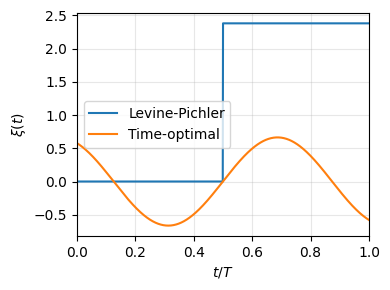

In [3]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
pulse_ansatz_1 = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const
)
initial_params1=(1,[-0.37736613*8.585308327286219],[2.38073847],[8.585308327286219])


pulse_ansatz_2 = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params2=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])

duration = 1
num_points=1024
times = jnp.linspace(0, duration, num_points)
values1 = np.array(pulse_ansatz_1.evaluate_pulse_functions(times, initial_params1))
values2 = np.array(pulse_ansatz_2.evaluate_pulse_functions(times, initial_params2))

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(times, values1[1], label= 'Levine-Pichler')
ax.plot(times, values2[1], label= 'Time-optimal')
 
ax.set_xmargin(0)
ax.set_xlabel(r"$t /T$")
ylabel = r"$\xi(t)$"
ax.set_ylabel(ylabel)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig('Gate_phase_profiles.svg', format='svg')
plt.show()

**Plot phase profile for robust pulse**

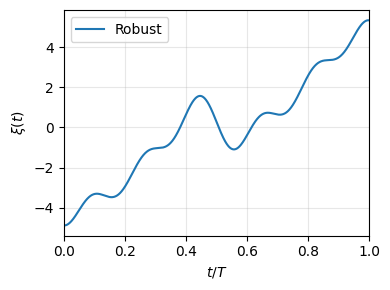

In [4]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
d=19.16385937372734
pulse_ansatz_3 = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
initial_params3 =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
duration = 1
num_points=1024
times = jnp.linspace(0, duration, num_points)

values3 = np.array(pulse_ansatz_3.evaluate_pulse_functions(times, initial_params3))
fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(times, values3[1], label= 'Robust')
ax.set_xmargin(0)
ax.set_xlabel(r"$t /T$")
ylabel = r"$\xi(t)$"
ax.set_ylabel(ylabel)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig('Gate_phase_profiles_Robust.svg', format='svg')
plt.show()

**Re-define plot pulse with saving to file**

In [5]:
from typing import cast
def plot_pulse(
    pulse: PulseAnsatz,
    params: PulseParams,
    *,
    plot_detuning: bool = True,
    plot_phase: bool = True,
    plot_rabi: bool = True,
    subtract_phase_offset: bool = False,
    num_points: int = 1024,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    
    duration = params[0]

    times = jnp.linspace(0, duration, num_points)

    # Evaluated pulse
    selector = [plot_detuning, plot_phase, plot_rabi]

    values = np.array(pulse.evaluate_pulse_functions(times, params))
    if subtract_phase_offset:
        values[1] -= values[1][0]
    values = values[selector]

    labels = np.array(
        [
            r"$\Delta(t)$",
            r"$\xi(t)$",
            r"$\Omega(t)$",
        ]
    )[selector]

    ylabel = ", ".join(
        np.array(
            [
                r"$T\Delta $",
                r"$\xi$ [rad]",
                r"$T\Omega $",
            ]
        )[selector]
    )

    # Plot pulse
    owns_ax = ax is None

    if owns_ax:
        fig, ax = plt.subplots(figsize=(4, 3))
    else:
        assert ax is not None
        fig = cast(plt.Figure, ax.figure)

    for v, label in zip(values, labels):
        ax.plot(times, v, label=label)

    if owns_ax:
        ax.set_xmargin(0)
        ax.set_xlabel(r"$t/ T$")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
    plt.savefig('Pulse_plot.svg', format='svg')
    return fig, ax

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

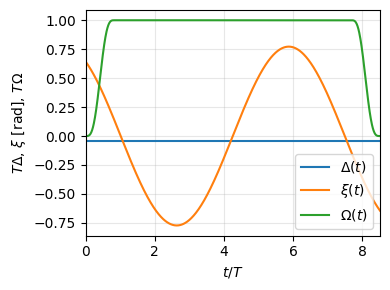

In [7]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
initial_params=(2.09722135*4.058348807763706, [-0.09393892/2.09722135 ], [0.73884332, 0.77225565], [1, 0.19713572])
plot_pulse(pulse_ansatz,initial_params)

In [8]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states).item()

1.0000000018113213

**Here we investigate robustness of different gate schemes to variation of Rabi frequencies**

**Calculating robustness to variation of Rabi frequency for Levine-Pichler gate**

In [6]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevine=[]
d=8.585308327286219
optimized_params=(1, [-0.37736613*d], [2.38073847], [d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=10000, decay=0.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[(1+Eps[i])*d]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevine

[0.007345069924872827,
 0.004775024112595672,
 0.0027263032039486212,
 0.0012262143548218418,
 0.00030604804046518996,
 5.66959725833982e-07,
 0.0003473889794026741,
 0.0013862664796316926,
 0.0031582696728894577,
 0.0057048816531645175,
 0.009067020914679036]

**Calculating robustness for time-optimal gate**

In [8]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz  = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
d=7.6266
optimized_params =(1, [0.03126*d], [0.82, 0.664], [1*d])
FTO=[]
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=10000, decay=0.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTO.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FTO

[0.008035980228460748,
 0.005202776299990108,
 0.00296076695969405,
 0.001330170329732483,
 0.0003346151273813103,
 6.381425253776385e-07,
 0.0003570613383682142,
 0.0014342495031576252,
 0.0032632523638606026,
 0.00587483819768031,
 0.009298429917820705]

**Calculating robustness to variation of Rabi frequency for robust gate**

In [9]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)

FRobust=[]
d=19.16385937372734
const_end_new_metrics_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=10000, decay=0.0)
for i in range(len(Eps)):
    initial_params=const_end_new_metrics_params[0],const_end_new_metrics_params[1],const_end_new_metrics_params[2],[0.91540583*d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const,  initial_params)
    FRobust.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobust

[2.593268116379832e-05,
 1.6485045917113972e-05,
 1.1375831316051688e-05,
 9.092880688732485e-06,
 8.443446449346581e-06,
 8.620552054749986e-06,
 9.287520555623097e-06,
 1.0678510476425096e-05,
 1.36919065938379e-05,
 1.9980913975925496e-05,
 3.2024767340543825e-05]

**Comparing robustness to variation of Rabi frequency for three gate schemes**

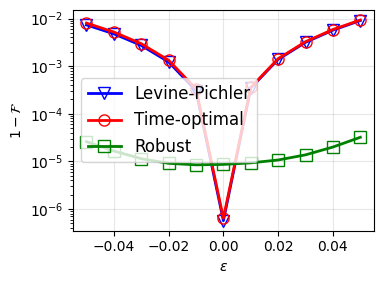

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Eps, FLevine, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)
# Plot the second series
ax.plot(Eps, FTO, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Eps, FRobust, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Robustness.svg', format='svg')
# Display the plot
plt.show()

`**Defining the class for individual addressing with finite blockade strength**

In [11]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateInd:

    def __init__(self, s: float,    Vnn: float):
        self._s = s
        self._Vnn = Vnn
 
    
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex),   jnp.array([1,0], dtype=complex),  jnp.array([1,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5],
                   [Omega* jnp.exp(1j * Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            s=self._s
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s],
                   [Omega* jnp.exp(1j * Xi)*s*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            V=self._Vnn
            s=self._s
            return jnp.array(
                    [
                      [0, Omega*jnp.exp(-1j * Xi)*0.5, Omega*jnp.exp(-1j * Xi)*0.5*s, 0], 
                      [Omega*jnp.exp(1j * Xi)*0.5, Delta, 0, Omega* jnp.exp(-1j * Xi)*0.5*s], 
                      [Omega* jnp.exp(1j * Xi)*0.5*s, 0,  Delta, Omega* jnp.exp(-1j * Xi)*0.5], 
                      [0, Omega* jnp.exp(1j * Xi)*0.5*s, Omega*jnp.exp(1j * Xi)*0.5, 2.0*Delta + V]
                    ]       
                )
        return hamiltonian1, hamiltonian2, hamiltonian3

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Calculating robustness to asymmetry of Rabi frequencies for amplitude-robust gate**

In [12]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)

FRobustAlpha=[]
d=19.16385937372734
const_end_new_metrics_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])

for i in range(len(Eps)):
    gate = CZGateInd(s=1+alpha[i],Vnn=10000)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const,  const_end_new_metrics_params )
    FRobustAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobustAlpha

[0.00021778085282941895,
 0.00013208571530121116,
 6.934389485124814e-05,
 2.8287064136045537e-05,
 8.144997423742417e-06,
 8.618655809145004e-06,
 2.9854703691989393e-05,
 7.241613476927089e-05,
 0.0001372522851712521,
 0.00022566942927160216,
 0.0003393016707133878]

**Calculating robustness to asymmetry of Rabi frequencies for Levine-Pichler gate**

In [13]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevineAlpha=[]
d=8.585308327286219
optimized_params=(1, [-0.37736613*d], [2.38073847], [1*d])
for i in range(len(Eps)):
    gate = CZGateInd(s=1+alpha[i],Vnn=9000)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz ,  optimized_params )
    FLevineAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevineAlpha

[0.003903617954136407,
 0.002480241474584144,
 0.0013850463072067054,
 0.0006113842138197878,
 0.00015232554146304977,
 6.99731155129335e-07,
 0.00014913467948907133,
 0.0005900944389298779,
 0.0013159150491455218,
 0.00231883870251548,
 0.0035910447962156367]

In [15]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
optimized_params=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])
FTOAlpha=[]
 
for i in range(len(Eps)):
    gate = CZGateInd(s=1+alpha[i],Vnn=9000)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz ,  optimized_params )
    FTOAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FTOAlpha

[0.005119328276440127,
 0.003274722919706319,
 0.0018421926210955286,
 0.0008202626739274299,
 0.00020709883764225,
 5.438819512537663e-07,
 0.0001981536333689471,
 0.0007972326801974905,
 0.0017948691757897484,
 0.003187968661961138,
 0.0049732864723717185]

**Plot comparison of robustness to asymmetry**

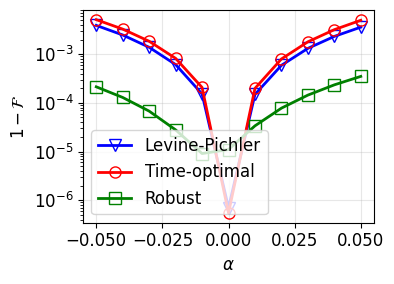

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(alpha, FLevineAlpha, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)
# Plot the second series
ax.plot(alpha, FTOAlpha, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(alpha, FRobustAlpha, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\alpha $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessAlpha.svg', format='svg')
# Display the plot
plt.show()

**Defining pulse profiles with gradient of Rabi frequency**

**Defining linear profile of Rabi frequency**

In [18]:
def lin_profile(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    Rabi0 = ansatz_params[0]
    Rabi1 = ansatz_params[1]
    return Rabi0+(Rabi1-Rabi0)*t/duration

**Re-defining amplitude-robust gate with gradient of Rabi frequency**

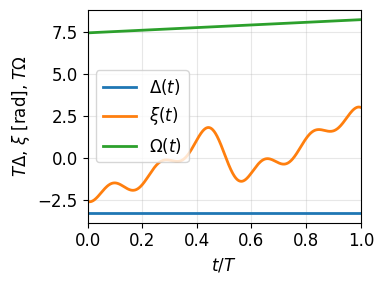

In [19]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
initial_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d*0.95,0.91540583*d*1.05])
plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

In [24]:
d=19.16385937372734
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
initial_params =  (d, [-0.37987234 ], [0.43832597 , 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583,0.91540583*0.999 ])
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states)

Array(0.00027025, dtype=float64)

**Calculating robustness of amplitude-robust gate with gradient of Rabi frequency**

In [22]:
d=19.16385937372734
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
initial_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
FRobustLin=[]
for i in range(len(Linlist)):
    initial_params=initial_params[0],initial_params[1],initial_params[2],[(1-0.5*Linlist[i])*0.91540583*d,(1+0.5*Linlist[i])*0.91540583*d]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FRobustLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobustLin

[0.029291400122982036,
 0.0073785706242415205,
 7.318811161560745e-07,
 0.007410672996252643,
 0.029322129473123182]

**Robustness of time-optimal gate with gradient of Rabi frequency**

In [46]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab, rabi_ansatz=lin_profile
) 
d=7.6266
optimized_params =(1, [0.03126*d], [0.82, 0.664], [1*d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
FTOLin=[]
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
for i in range(len(Linlist)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1-0.5*Linlist[i]),d*(1+0.5*Linlist[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTOLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FTOLin

[0.00431115686318484,
 0.001079063030581695,
 5.5350276473298266e-08,
 0.0010790633079461598,
 0.004311157436033053]

**Robustness of Levine-Pichler gate with gradient of Rabi frequency**

In [44]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=lin_profile
) 
d=8.585308327286219
optimized_params=(1, [-0.37736613*d], [2.38073847], [d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
FLevineLin=[]
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
for i in range(len(Linlist)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1-0.5*Linlist[i]),d*(1+0.5*Linlist[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevineLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevineLin

[0.00790112233142326,
 0.001979567981809538,
 7.85302844974467e-09,
 0.0019794854019540287,
 0.007901103551271493]

**This plot compares robustness of gate fidelities to gradient of Rabi frequency**

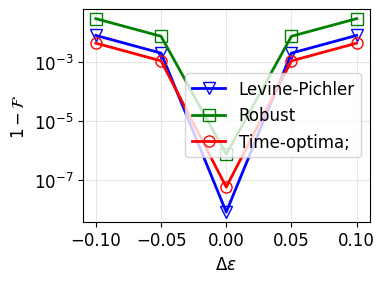

In [47]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Linlist, FLevineLin, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FRobustLin, label='Robust', color='green', marker='s', mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FTOLin, label='Time-optima;', color='red', marker='o', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Delta\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('Robustness_lin_plot.svg', format='svg')
ax.grid(alpha=0.3)
# Display the plot
plt.show()